# Shallow-Squat — Evaluation

Benchmark evaluation of the CVCSPC ensemble on the official 540-crop Shallow-Squat test split, using the same F1 metric and split as Parmar et al. (ECCV 2022). All numbers and figures regenerate from the frozen `results.pkl` (no GPU). Headline: ensemble test F1 0.8902 (best single model 0.8961, PR-AUC 0.9668), above the paper's CVCSPC row (0.8694) and our supervised baseline (0.875).

## Setup

In [1]:
import csv
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import average_precision_score, precision_recall_curve

_CANDS = [Path("backend/data/benchmark/shallow/results.pkl"),
          Path("../../backend/data/benchmark/shallow/results.pkl")]
R = pickle.load(open(next(p for p in _CANDS if p.exists()), "rb"))
S = np.asarray(R["ensemble_test_scores"], dtype=float)
Y = np.asarray(R["test_labels"]).astype(int)
TH = float(R["best_threshold"])
print("test crops:", len(Y), "| positives:", int(Y.sum()), "| threshold:", round(TH, 4))

FIG = Path("docs/figures") if Path("docs/figures").exists() else Path("../../docs/figures")
EVAL = Path("docs/eval") if Path("docs/eval").exists() else Path("../../docs/eval")
FIG.mkdir(parents=True, exist_ok=True)
EVAL.mkdir(parents=True, exist_ok=True)

test crops: 540 | positives: 236 | threshold: 0.3954


## 1. Headline test F1 — per-seed vs ensemble

The three seeds land at 0.8961 / 0.8902 / 0.8825; the mean-score ensemble equals the
1337-seed value (0.8902) and the best single model is seed 42 (0.8961). The ensemble is the
reported model (variance-reduced operating point).

In [2]:
f1 = R["test_f1"]
per_seed = f1["per_seed"]
print(f"{'model':<22}{'test F1':>9}")
for s in sorted(per_seed):
    print(f"{'seed ' + str(s):<22}{per_seed[s]:>9.4f}")
print(f"{'CVCSPC ensemble':<22}{f1['cvcspc_ensemble']:>9.4f}")
print(f"{'best single model':<22}{f1['single_model']:>9.4f}")
print(f"{'supervised baseline':<22}{R['baseline_control']['test_f1']:>9.4f}")

model                   test F1
seed 7                   0.8825
seed 42                  0.8961
seed 1337                0.8902
CVCSPC ensemble          0.8902
best single model        0.8961
supervised baseline      0.8750


## 2. PR curve with operating point

Precision-recall over the ensemble test scores; the marker is the val-tuned decision
threshold (`best_threshold` ≈ 0.395). The PR-AUC (average precision) is in the title.

PR-AUC: 0.9668 (stored 0.9668)
operating point @thr 0.3954: precision 0.8415, recall 0.9449


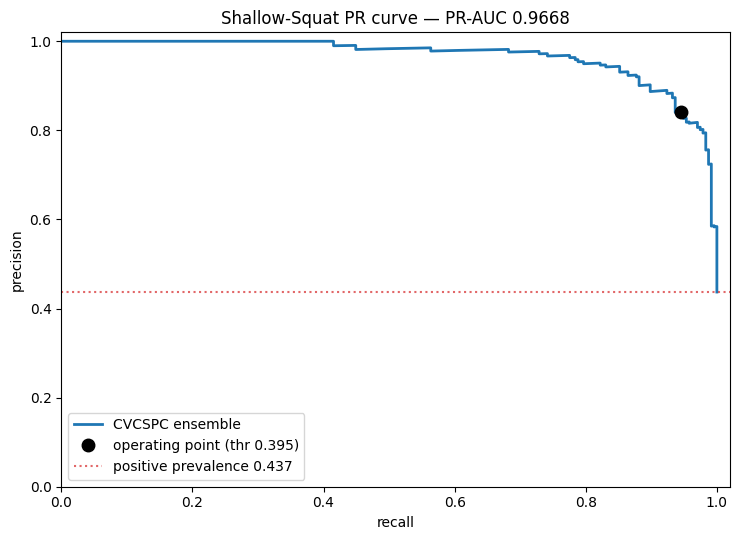

In [3]:
prec, rec, thr = precision_recall_curve(Y, S)
ap = average_precision_score(Y, S)
op_pred = (S >= TH).astype(int)
tp = int(((op_pred == 1) & (Y == 1)).sum())
fp = int(((op_pred == 1) & (Y == 0)).sum())
fn = int(((op_pred == 0) & (Y == 1)).sum())
op_prec = tp / (tp + fp)
op_rec = tp / (tp + fn)
print(f"PR-AUC: {ap:.4f} (stored {R['test_pr_auc']:.4f})")
print(f"operating point @thr {TH:.4f}: precision {op_prec:.4f}, recall {op_rec:.4f}")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(rec, prec, "C0-", lw=2, label="CVCSPC ensemble")
ax.plot(op_rec, op_prec, "ko", ms=9,
        label=f"operating point (thr {TH:.3f})")
ax.axhline(Y.mean(), color="C3", ls=":", alpha=0.7,
           label=f"positive prevalence {Y.mean():.3f}")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.set_title(f"Shallow-Squat PR curve — PR-AUC {ap:.4f}")
ax.legend(loc="lower left")
fig.tight_layout()
plt.savefig(FIG / "shallow_squat_pr_curve.png", dpi=130, bbox_inches="tight")
plt.show()

## 3. Confusion matrix at the val-tuned threshold

`test_confusion` = `[[TN, FP], [FN, TP]]` at the operating threshold. TP+FN matches the 236
test positives; TN+FP the 304 negatives.

confusion [[TN, FP], [FN, TP]]:
 [[262  42]
 [ 13 223]]


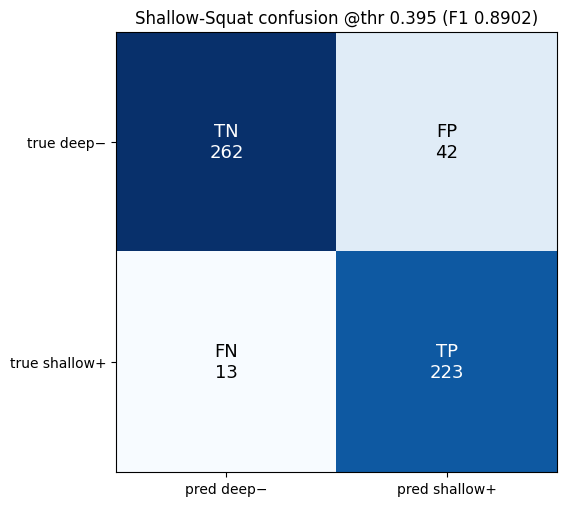

In [4]:
cm = np.asarray(R["test_confusion"])
print("confusion [[TN, FP], [FN, TP]]:\n", cm)
fig, ax = plt.subplots(figsize=(5.6, 5.2))
ax.imshow(cm, cmap="Blues")
labels2d = [["TN", "FP"], ["FN", "TP"]]
mx = cm.max()
for (rr, cc), v in np.ndenumerate(cm):
    ax.text(cc, rr, f"{labels2d[rr][cc]}\n{v}", ha="center", va="center",
            fontsize=13, color="white" if v > mx / 2 else "black")
ax.set_xticks([0, 1])
ax.set_xticklabels(["pred deep−", "pred shallow+"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["true deep−", "true shallow+"])
ax.set_title(f"Shallow-Squat confusion @thr {TH:.3f} (F1 {f1['cvcspc_ensemble']:.4f})")
fig.tight_layout()
plt.savefig(FIG / "shallow_squat_confusion_matrix.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. F1 vs paper + our baseline

Grouped bar against the published Squat shallow-depth rows. Ours in blue, paper in red, the
paper's CVCSPC target marked with a dotted line. Our CVCSPC ensemble (0.8902) edges the
paper's CVCSPC (0.8694) and clears their SimSiam (0.8286) and OpenPose-TDM (0.8340) baselines.

our baseline (supervised)   0.8750
our CVCSPC (ensemble)       0.8902
paper CVCSPC                0.8694
paper SimSiam               0.8286
paper OpenPose-TDM          0.8340


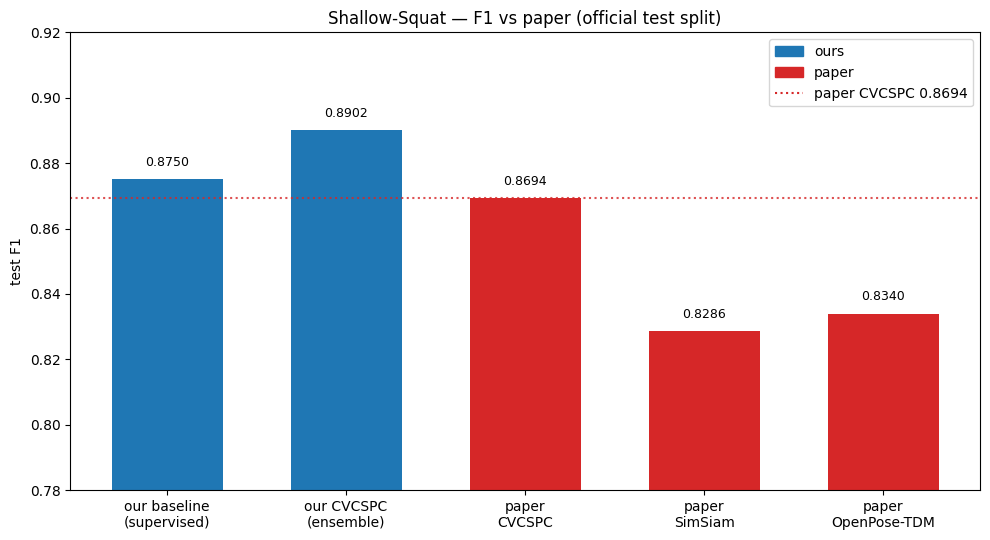

In [5]:
paper = R["paper_targets"]
base_f1 = R["baseline_control"]["test_f1"]
cvc_f1 = f1["cvcspc_ensemble"]
rows = [
    ("our baseline\n(supervised)", base_f1, "ours"),
    ("our CVCSPC\n(ensemble)", cvc_f1, "ours"),
    ("paper\nCVCSPC", paper["cvcspc"], "paper"),
    ("paper\nSimSiam", paper["simsiam"], "paper"),
    ("paper\nOpenPose-TDM", paper["openpose_tdm"], "paper"),
]
for name, v, _ in rows:
    print(f"{name.replace(chr(10), ' '):<28}{v:.4f}")

x = np.arange(len(rows))
colors = ["#1f77b4" if kind == "ours" else "#d62728" for _, _, kind in rows]
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(x, [v for _, v, _ in rows], 0.62, color=colors)
for b, (_, v, _) in zip(bars, rows):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.004, f"{v:.4f}", ha="center", fontsize=9)
ax.axhline(paper["cvcspc"], color="#d62728", ls=":", alpha=0.8,
           label=f"paper CVCSPC {paper['cvcspc']:.4f}")
ax.set_xticks(x)
ax.set_xticklabels([n for n, _, _ in rows])
ax.set_ylabel("test F1")
ax.set_ylim(0.78, 0.92)
ax.set_title("Shallow-Squat — F1 vs paper (official test split)")
handles = [plt.Rectangle((0, 0), 1, 1, color="#1f77b4"),
           plt.Rectangle((0, 0), 1, 1, color="#d62728")]
ax.legend(handles + [plt.Line2D([0], [0], color="#d62728", ls=":")],
          ["ours", "paper", f"paper CVCSPC {paper['cvcspc']:.4f}"], loc="upper right")
fig.tight_layout()
plt.savefig(FIG / "shallow_squat_f1_vs_paper.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Score distributions (supplementary)

Ensemble test scores split by true label, with the operating threshold marked — the two
classes separate cleanly, consistent with the 0.9668 PR-AUC.

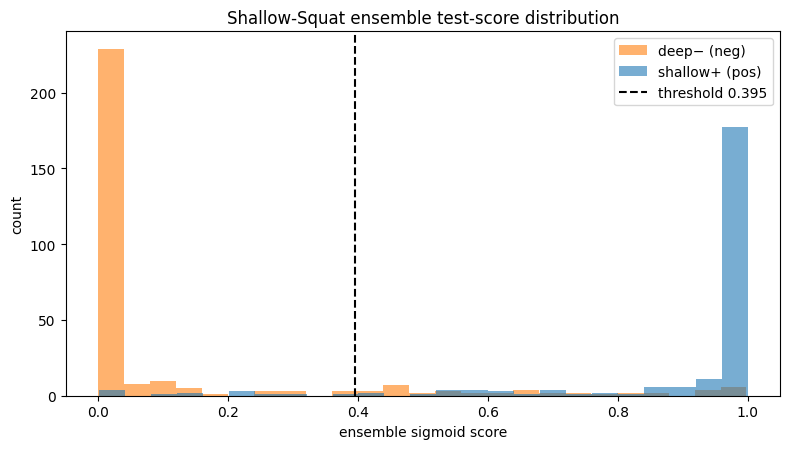

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.hist(S[Y == 0], bins=25, alpha=0.6, color="C1", label="deep− (neg)")
ax.hist(S[Y == 1], bins=25, alpha=0.6, color="C0", label="shallow+ (pos)")
ax.axvline(TH, color="k", ls="--", label=f"threshold {TH:.3f}")
ax.set_xlabel("ensemble sigmoid score")
ax.set_ylabel("count")
ax.set_title("Shallow-Squat ensemble test-score distribution")
ax.legend()
fig.tight_layout()
plt.show()

## 6. Honest reporting

- **No paper supervised-ImageNet baseline row exists** for this task, so OUR supervised
  baseline (0.875) is the only supervised control. The SSL lift is therefore measured
  against our own control: CVCSPC − baseline = **+0.0152**.
- **val → test gap = 0.0217** (val-F1 0.9119 vs test-F1 0.8902) — small, so the val-tuned
  threshold transfers and there is no meaningful overfitting.
- **Loss deviation:** quoted verbatim from `results.pkl`.

In [7]:
print("baseline (supervised) test-F1 :", R["baseline_control"]["test_f1"])
print("CVCSPC ensemble test-F1       :", R["test_f1"]["cvcspc_ensemble"])
print("CVCSPC ensemble val-F1        :", round(R["cvcspc_ensemble_val_f1"], 4))
print("SSL lift (CVCSPC − baseline)  :", round(R["ssl_lift"], 4))
print("val→test gap                  :", round(R["val_test_gap"], 4))
print("loss deviation note           :", R["loss_deviation_note"])

baseline (supervised) test-F1 : 0.875
CVCSPC ensemble test-F1       : 0.8902195608782435
CVCSPC ensemble val-F1        : 0.9119
SSL lift (CVCSPC − baseline)  : 0.0152
val→test gap                  : 0.0217
loss deviation note           : SSL pretrained with the 3-term code loss (train_test.py:68); paper Eq.1 is 2-term.


## 7. Write per-crop test scores CSV

In [8]:
out = EVAL / "shallow_squat_test_scores.csv"
with open(out, "w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["score", "label"])
    for sc, yl in zip(S, Y):
        w.writerow([round(float(sc), 6), int(yl)])
print("wrote", out, "rows:", len(S))

wrote ..\..\docs\eval\shallow_squat_test_scores.csv rows: 540


## Notes
- All figures from `results.pkl` — reproducible without GPU.
- 3-seed mean-score ensemble; reported at the val-tuned `best_threshold`.
- Benchmark (in-the-wild gym) crops; live phone-camera input is out-of-domain.